In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

In [3]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
acc_lr = accuracy_score(y_test, lr.predict(X_test))

In [7]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)
acc_svm = accuracy_score(y_test, svm.predict(X_test))

In [9]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
acc_dt = accuracy_score(y_test, dt.predict(X_test))
print("Logistic Regression Accuracy:", acc_lr)
print("SVM Accuracy:", acc_svm)

Logistic Regression Accuracy: 0.7916666666666666
SVM Accuracy: 0.9583333333333334


In [21]:
estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier(max_depth=3, random_state=42))
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train, y_train)
acc_stack = accuracy_score(y_test, stack_model.predict(X_test))
print("Stacking Classifier Accuracy:", acc_stack)

Stacking Classifier Accuracy: 1.0


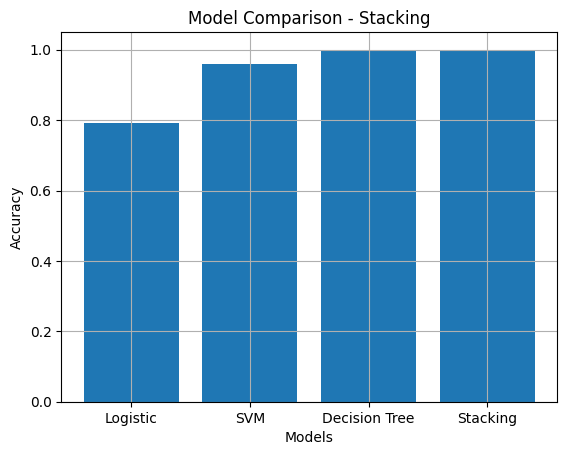

In [23]:
models = ["Logistic", "SVM", "Decision Tree", "Stacking"]
accuracies = [acc_lr, acc_svm, acc_dt, acc_stack]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Stacking")
plt.grid()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_scores = cross_val_score(dt, X, y, cv=5)

stack_model = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('svm', SVC(probability=True)),
        ('dt', DecisionTreeClassifier(max_depth=3))
    ],
    final_estimator=LogisticRegression()
)

stack_scores = cross_val_score(stack_model, X, y, cv=5)

print("Decision Tree CV Accuracy:", dt_scores.mean())
print("Stacking CV Accuracy:", stack_scores.mean())

Decision Tree CV Accuracy: 0.9916666666666668
Stacking CV Accuracy: 0.9916666666666668


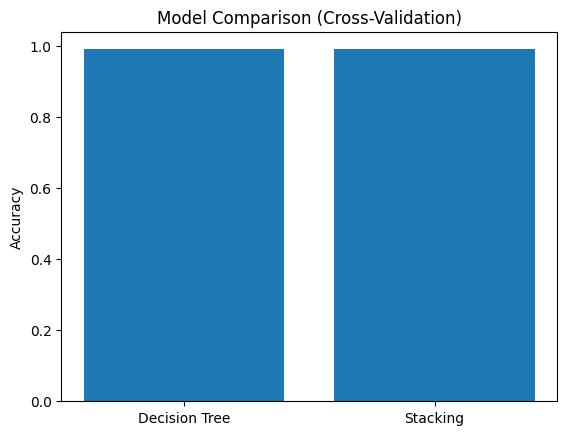

In [24]:
models = ["Decision Tree", "Stacking"]
accuracies = [dt_scores.mean(), stack_scores.mean()]

plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Comparison (Cross-Validation)")
plt.show()

In [26]:
print(X.corrwith(y))

Age            -0.049525
Cholesterol     0.516027
MaxHeartRate   -0.090560
RestingBP       0.463780
dtype: float64
